# Predicting Electrocatalyst Performance with Random Forests and MLPs

This project models electrocatalytic activity for the hydrogen evolution reaction. The workflow compares classification with random forests and regression with multilayer perceptrons (MLPs), while using train/validation/test splits, cross-validation, hyperparameter tuning, and permutation feature importance to evaluate model behavior.


##### Objectives:

- Split data into training, validation, and testing sets using train_test_split
- Build random forest models and tune hyperparameters
- Build multilayer perceptron models and tune hyperparameters
- Cross-validate model performance using 5-fold cross-validation
- View and analyze decision trees that make up the chosen random forest models
- Compare MLP models using normalized vs. non-normalized data
- Critically evaluate model performance and select a final model with the most promising metrics for accurate, generalizable predictions

##### Tools and libraries

- Python
- pandas
- NumPy
- scikit-learn
- matplotlib

## Part 1: Preparing Training, Validation, and Test Splits

### 1.1 Creating a 70/15/15 Split

First, training, validation, and test splits are created using 70% of the data for training, 15% for validation, and 15% for final testing. Data is shuffled so that the split is randomized rather than dependent on the order of the original CSV file.

In [24]:
# Import packages

import os
import pandas as pd

PATH = '../data/'
DATA_FILE = 'Exercise 4 data.csv'

# Create DataFrame to prepare for ML

df = pd.read_csv(os.path.join(PATH, DATA_FILE))
df = df.dropna()

# Append new column to DataFrame that denotes good and bad catalysts for classification

cl = []

for i in df.iloc[:, -1]:
    if abs(i) < 0.6:
        val = 'good'
    elif abs(i) >= 0.6:
        val = 'bad'
    else:
        val = 'N/A'
    cl.append(val)

df['Classification'] = cl
df

,Experiment,V,Cr,Mg,Fe,Co,Ni,Cu,S,Se,P,Voltage,Time,Overpotential V at 50.0 mA/cm2,Classification
0,exp1,5,5,25,0,5,0,10,15,0,5,-1.2,90,-0.5917,good
1,exp2,0,5,5,10,10,0,0,15,10,0,-1.2,60,-0.7847,bad
2,exp3,5,10,10,0,10,0,10,5,10,5,-1.3,120,-0.6637,bad
3,exp4,5,0,0,25,0,10,0,10,10,10,-1.4,90,-0.5297,good
4,exp5,0,10,0,0,5,15,5,10,10,15,-1.3,120,-0.7347,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,exp591,0,0,0,5,30,15,0,0,20,0,-1.5,180,-0.4607,good
587,exp592,0,0,0,0,0,20,0,0,0,50,-1.0,180,-0.5307,good
588,exp593,0,0,0,0,5,20,20,5,0,25,-1.5,180,-0.3447,good
589,exp594,0,5,0,0,0,45,0,0,0,20,-1.5,180,-0.3757,good


In [25]:
# Import package

import numpy as np

# Create arrays of X and y values for train_test_split

X_placeholder = np.array(df.iloc[:, 1:-2])
y_placeholder = np.array(df.iloc[:, -2:])
y_placeholder

array([[-0.5917, 'good'],
       [-0.7847, 'bad'],
       [-0.6637, 'bad'],
       ...,
       [-0.3447, 'good'],
       [-0.3757, 'good'],
       [-0.7457, 'bad']], shape=(545, 2), dtype=object)

In [26]:
# Import package

from sklearn.model_selection import train_test_split

# Run train_test_split to create test set and validation sets (Shuffle on for randomization)

X, X_test, y, y_test = train_test_split( 
                X_placeholder, y_placeholder, test_size=0.15, # Test set size of 15%
                shuffle=True,
                random_state=42)

X, X_val, y, y_val = train_test_split( 
                X, y, test_size=0.18, # Validation set size of 15% (0.18 * 0.85 ~ 0.15)
                shuffle=True,
                random_state=42)

In [27]:
# Create features list

features = df.columns.drop(['Experiment', 'Overpotential V at 50.0 mA/cm2', 'Classification']).tolist()

# Create training DataFrame

training_1 = pd.DataFrame(X, columns=features)
training_1['Classification'] = y[:, 1]
training_1['Overpotential'] = y[:, 0]
training_1

# Create validation DataFrame

validation_1 = pd.DataFrame(X_val, columns=features)
validation_1['Classification'] = y_val[:, 1]
validation_1['Overpotential'] = y_val[:, 0]
validation_1

# Create test DataFrame

test_1 = pd.DataFrame(X_test, columns=features)
test_1['Classification'] = y_test[:, 1]
test_1['Overpotential'] = y_test[:, 0]
test_1

,V,Cr,Mg,Fe,Co,Ni,Cu,S,Se,P,Voltage,Time,Classification,Overpotential
0,0.0,0.0,0.0,5.0,15.0,0.0,25.0,10.0,15.0,0.0,-1.1,60.0,bad,-0.6777
1,0.0,5.0,0.0,0.0,0.0,25.0,5.0,10.0,0.0,10.0,-1.1,90.0,bad,-0.6037
2,0.0,0.0,10.0,10.0,0.0,0.0,0.0,5.0,0.0,40.0,-1.2,150.0,bad,-0.8787
3,0.0,5.0,5.0,5.0,15.0,10.0,0.0,5.0,20.0,5.0,-1.4,120.0,good,-0.5517
4,0.0,0.0,0.0,0.0,0.0,0.0,8.0,15.0,0.0,0.0,-1.4,150.0,bad,-0.6627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,15.0,0.0,10.0,0.0,20.0,0.0,0.0,20.0,5.0,0.0,-1.1,90.0,bad,-0.6167
78,10.0,0.0,0.0,0.0,15.0,10.0,0.0,20.0,5.0,10.0,-1.4,90.0,good,-0.4267
79,0.0,0.0,0.0,0.0,0.0,20.0,30.0,0.0,0.0,20.0,-1.5,60.0,good,-0.4767
80,0.0,5.0,15.0,5.0,0.0,5.0,0.0,15.0,10.0,10.0,-1.4,120.0,bad,-0.6417


### 1.2 Creating an 80/15/5 Split

The same process is repeated with a second split that uses more data for training: 80% training, 15% validation, and 5% testing for comparison of split sizes on model behavior.

In [28]:
# Run train_test_split to create new test and validation sets (shuffle for randomization)

X2, X2_test, y2, y2_test = train_test_split( 
                X_placeholder, y_placeholder, test_size=0.05, # Test set size of 5%
                shuffle=True,
                random_state=42)

X2, X2_val, y2, y2_val = train_test_split( 
                X2, y2, test_size=0.16, # Validation set size of 15% (0.16 * 0.95 ~ 0.15)
                shuffle=True,
                random_state=42)

In [29]:
# Create training DataFrame 2

training_2 = pd.DataFrame(X2, columns=features)
training_2['Classification'] = y2[:, 1]
training_2['Overpotential'] = y2[:, 0]
training_2

# Create validation DataFrame 2

validation_2 = pd.DataFrame(X2_val, columns=features)
validation_2['Classification'] = y2_val[:, 1]
validation_2['Overpotential'] = y2_val[:, 0]
validation_2

# Create test DataFrame 2

test_2 = pd.DataFrame(X2_test, columns=features)
test_2['Classification'] = y2_test[:, 1]
test_2['Overpotential'] = y2_test[:, 0]
test_2

,V,Cr,Mg,Fe,Co,Ni,Cu,S,Se,P,Voltage,Time,Classification,Overpotential
0,0.0,0.0,0.0,5.0,15.0,0.0,25.0,10.0,15.0,0.0,-1.1,60.0,bad,-0.6777
1,0.0,5.0,0.0,0.0,0.0,25.0,5.0,10.0,0.0,10.0,-1.1,90.0,bad,-0.6037
2,0.0,0.0,10.0,10.0,0.0,0.0,0.0,5.0,0.0,40.0,-1.2,150.0,bad,-0.8787
3,0.0,5.0,5.0,5.0,15.0,10.0,0.0,5.0,20.0,5.0,-1.4,120.0,good,-0.5517
4,0.0,0.0,0.0,0.0,0.0,0.0,8.0,15.0,0.0,0.0,-1.4,150.0,bad,-0.6627
5,5.0,0.0,10.0,0.0,0.0,10.0,0.0,5.0,15.0,0.0,-1.3,60.0,bad,-0.7367
6,0.0,0.0,5.0,10.0,25.0,5.0,5.0,5.0,10.0,5.0,-1.2,150.0,good,-0.4137
7,5.0,5.0,5.0,20.0,0.0,0.0,0.0,15.0,10.0,5.0,-1.5,60.0,bad,-0.8547
8,0.0,0.0,8.0,8.0,0.0,0.0,0.0,7.0,7.0,0.0,-1.1,60.0,bad,-0.8747
9,0.0,0.0,0.0,20.0,0.0,0.0,15.0,20.0,0.0,0.0,-1.5,60.0,bad,-0.6567


## Part 2: Random Forest Classification

For the classification task, catalysts with `|overpotential| < 0.6` are defined as **good** and catalysts with `|overpotential| >= 0.6` as **bad**. The goal is to predict whether a catalyst is good or bad from the experimental variables.

Feature scaling is not applied because random forests are insensitive to feature magnitude.

### 2.1 Class Balance

Before training a model, the percentage of good and bad catalysts are calculated for the full dataset. This gives important context for interpreting precision, recall, and F1 score.

In [30]:
# Calculate percentage of good and bad catalysts

# Initialize variables

total = len(df)
num_good = 0
num_bad = 0
num_mid = 0

# Calculate numbers of good and bad catalysts

for row, i in enumerate(df.iloc[:, -2]):
    if abs(i) < 0.6:
        num_good += 1
    elif abs(i) >= 0.6:
        num_bad += 1
    else:
        num_mid += 1

# Calculate percentages of good and bad catalysts

percent_good = np.round(num_good / total * 100, 2)
percent_bad = np.round(num_bad / total * 100, 2)
percent_mid = np.round(num_mid / total * 100, 2)

# Print percentages of good and bad catalysts

print(f'The percentage of good catalysts is {percent_good} percent')
print(f'The percentage of bad catalysts is {percent_bad} percent')
print(f'The percentage exactly at the threshold is {percent_mid} percent')

The percentage of good catalysts is 37.98 percent
The percentage of bad catalysts is 62.02 percent
The percentage exactly at the threshold is 0.0 percent


In [31]:
# Create y variables for Random Forest Classifier analysis

y_rf = y[:, 1]
y_rf_val = y_val[:, 1]
y_rf_test = y_test[:, 1]
y_rf2 = y2[:, 1]
y_rf2_val = y2_val[:, 1]
y_rf2_test = y2_test[:, 1]

### 2.2 Baseline Random Forest on the 70/15/15 Split

First, a default random forest classifier is trained on the training split and calculates true positives (tp), false positives (fp), false negatives (fn), true negatives (tn), precision, recall, and F1 score.

In [32]:
# Import package

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest Classifier and train it

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X, y_rf)

# Create function for calculating statistics of interest from one data split

def statistics_ML(model, X, y, settype):

    # Initialize variables

    tp = 0
    fp = 0
    fn = 0
    tn = 0

    total = len(X)

    # Calculate numbers of tp, fp, fn, and tn based on predicted values of X data

    for i in range(len(X)):
        feat_vals = np.array([X[i].tolist()])
        result = model.predict(feat_vals)
        if result[0] == 'good' and y[i] == 'good':
            tp += 1
        elif result[0] == 'good' and y[i] == 'bad':
            fp += 1
        elif result[0] == 'bad' and y[i] == 'good':
            fn += 1
        elif result[0] == 'bad' and y[i] == 'bad':
            tn += 1

    # Calculate percentages of tp, fp, fn, and tn

    tpp = np.round(tp / total * 100, 1)
    fpp = np.round(fp / total * 100, 1)
    fnp = np.round(fn / total * 100, 1)
    tnp = np.round(tn / total * 100, 1)

    # Print percentages

    print(f'The percentage of true positives against {settype} set 1 is {tpp} percent')
    print(f'The percentage of false positives against {settype} set 1 is {fpp} percent')
    print(f'The percentage of false negatives against {settype} set 1 is {fnp} percent')
    print(f'The percentage of true negatives against {settype} set 1 is {tnp} percent')

    # Calculate precision, recall, and F1 score against X data

    precision = np.round(tp / (tp + fp), 2)
    recall = np.round(tp / (tp + fn), 2)
    F1 = np.round(2 * precision * recall / (precision + recall), 2)

    # Print values

    print(f'The precision against {settype} set 1 is {precision}')
    print(f'The recall against {settype} set 1 is {recall}')
    print(f'The F1 score against {settype} set 1 is {F1}')

# Run this function against the training 1 data

statistics_ML(rfc, X, y_rf, 'training')

The percentage of true positives against training set 1 is 39.6 percent
The percentage of false positives against training set 1 is 0.0 percent
The percentage of false negatives against training set 1 is 0.0 percent
The percentage of true negatives against training set 1 is 60.4 percent
The precision against training set 1 is 1.0
The recall against training set 1 is 1.0
The F1 score against training set 1 is 1.0


### 2.3 Baseline Validation Performance

Next, the same model is evaluated on the validation split to see whether the training performance generalizes to held-out data.

In [33]:
# Run this function against the validation 1 data

statistics_ML(rfc, X_val, y_rf_val, 'validation')

The percentage of true positives against validation set 1 is 21.4 percent
The percentage of false positives against validation set 1 is 14.3 percent
The percentage of false negatives against validation set 1 is 14.3 percent
The percentage of true negatives against validation set 1 is 50.0 percent
The precision against validation set 1 is 0.6
The recall against validation set 1 is 0.6
The F1 score against validation set 1 is 0.6


### 2.4 Five-Fold Cross-Validation

The original training and validation data are then combined and 5-fold cross-validation is used. This gives a more stable estimate of performance than relying on one individual split.

In [ ]:
# Import packages

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.base import clone

# Create combined X and y training + validation 1 arrays

X_train_val_1 = np.concatenate((X, X_val),axis=0)
y_rf_train_val_1 = np.concatenate((y_rf, y_rf_val),axis=0)

# Create k-fold variable with desired attributes

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create function to calculate means and standard deviations for each statistic of interest

def report_metrics(name, scores):
        print(f"\n{name} Set Metrics:")
        for metric in ['precision', 'recall', 'f1']:
            mean = np.mean(scores[metric])
            std = np.std(scores[metric])
            print(f"{metric.capitalize():<10}: Mean = {mean:.2f}, Std = {std:.2f}")

"""
Create function for training classifier on one split of training + validation data, 
then calculate statistics of interest against training and validation data
separately. Do this 5 times for 5 different splits.
"""

def cv_scores(X, y, model):

    # Initialize statistics arrays

    train_metrics = {'precision': [], 'recall': [], 'f1': []}
    val_metrics = {'precision': [], 'recall': [], 'f1': []}

    # # Generate training and validation folds from stratified k-fold cross-validation

    for train_index, val_index in cv.split(X, y):
        X_tr, X_val_fold = X[train_index], X[val_index]
        y_tr, y_val_fold = y[train_index], y[val_index]

        # Train a fresh copy of the model for this fold

        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)

        # Predict against training fold

        y_pred_train = fold_model.predict(X_tr)
        train_metrics['precision'].append(precision_score(y_tr, y_pred_train, pos_label='good'))
        train_metrics['recall'].append(recall_score(y_tr, y_pred_train, pos_label='good'))
        train_metrics['f1'].append(f1_score(y_tr, y_pred_train, pos_label='good'))

        # Predict against validation fold

        y_pred_val = fold_model.predict(X_val_fold)
        val_metrics['precision'].append(precision_score(y_val_fold, y_pred_val, pos_label='good'))
        val_metrics['recall'].append(recall_score(y_val_fold, y_pred_val, pos_label='good'))
        val_metrics['f1'].append(f1_score(y_val_fold, y_pred_val, pos_label='good'))

    # Display results, including means and standard deviations for each statistic

    report_metrics("Training", train_metrics)
    report_metrics("Validation", val_metrics)
    print("\n ================================")

# Run function using training + validation 1 data, and obtain metrics against training 1 and validation 1 data separately

cv_scores(X_train_val_1, y_rf_train_val_1, rfc)


Training Set Metrics:
Precision : Mean = 1.00, Std = 0.00
Recall    : Mean = 1.00, Std = 0.00
F1        : Mean = 1.00, Std = 0.00

Validation Set Metrics:
Precision : Mean = 0.74, Std = 0.06
Recall    : Mean = 0.66, Std = 0.09
F1        : Mean = 0.69, Std = 0.04



The standard deviations from the 5-fold cross-validation analysis show that model performance depends noticeably on how the data are partitioned into training and validation folds. Using only one split places too much weight on one possible division of the dataset. In this case, the single-split scores and the cross-validation averages are reasonably aligned, but that will not always happen. Cross-validation is therefore useful because it gives a broader and more reliable estimate of how the model performs across different train/validation partitions.

### 2.5 Checking for Overfitting

The model is likely overfitting because the cross-validation training scores are much higher than the validation scores. In particular, training scores near 1.00 with very small standard deviations suggest that the model is fitting the training folds extremely closely, while the lower validation scores show weaker generalization.

### 2.6 Inspecting Individual Trees

To understand why the random forest may be overfitting, one representative tree from the default model is plotted and the tree structure is used to guide hyperparameter tuning.

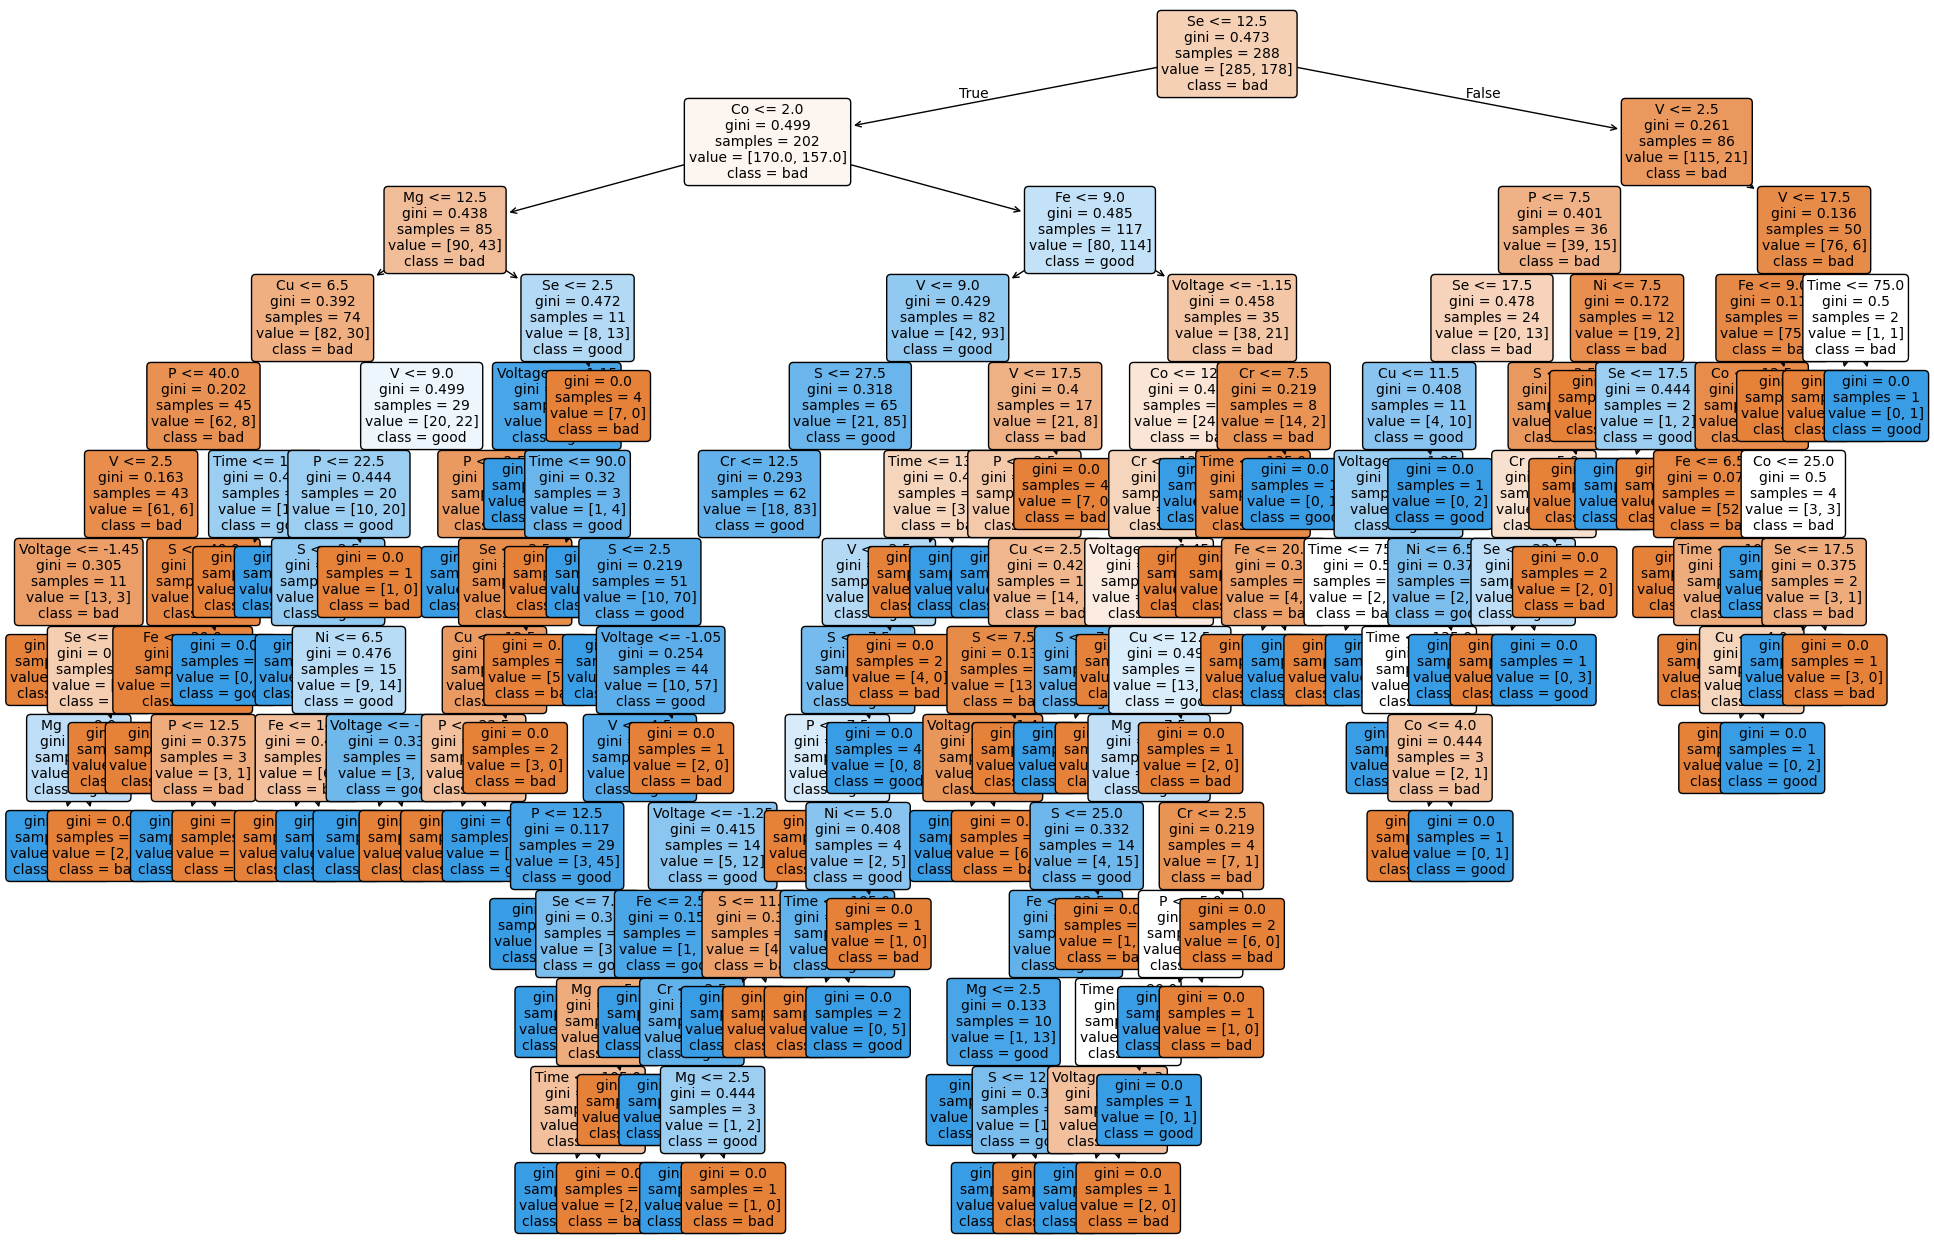

In [35]:
# Import packages

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

"""
Create function for printing a given tree in random forest based on its index
number, and map features and classes to features list and classes list.
"""

def tree_print(model, tree_number, features, classes):

    plt.figure(figsize=(24, 16))
    plot_tree(
        model.estimators_[tree_number],
        feature_names=features,
        class_names=classes,
        filled=True,
        rounded=True,
        impurity=True,
        fontsize=10
    )
    plt.show()

# Train model on all training + validation data before printing the first tree

rfc_train_val = clone(rfc)
rfc_train_val.fit(X_train_val_1, y_rf_train_val_1)

# Run function for default setting random forest model, printing the first tree

tree_print(rfc_train_val, 0, features, rfc_train_val.classes_)

In [36]:
num_trees = len(rfc.estimators_)
print(f'The number of trees being used in this model is {num_trees}')

The number of trees being used in this model is 100


The default number of trees is reasonable, but it is still worth trying different values to see whether the model becomes more stable.

The maximum tree depth in the plotted trees appears too deep, which can allow the model to memorize the training data and perform worse on validation and test data. `max_depth` is therefore reduced so that each tree is forced to remain more general.

`min_samples_split` is also increased because requiring more samples before a node can split helps prevent overly specific decision rules. Similarly, increasing `min_samples_leaf` prevents the model from creating leaf nodes that represent only a very small number of data points.

Bagging is already used to prevent trees from consistently seeing identical datasets that may lead to overfitting. This hyperparameter will not be altered during tuning.

Finally, different `max_features` settings are tested so that individual trees consider different numbers of features at each split. This can reduce correlation between trees and improve generalization with options such as `log2`, or reduce underfitting with settings like `None`.

### 2.7 Random Forest Hyperparameter Tuning

Four random forest hyperparameter combinations are tested using the same 5-fold cross-validation workflow. For each model, training and validation metrics are compared and representative trees are plotted.


Training Set Metrics:
Precision : Mean = 1.00, Std = 0.00
Recall    : Mean = 1.00, Std = 0.00
F1        : Mean = 1.00, Std = 0.00

Validation Set Metrics:
Precision : Mean = 0.74, Std = 0.06
Recall    : Mean = 0.66, Std = 0.09
F1        : Mean = 0.69, Std = 0.04



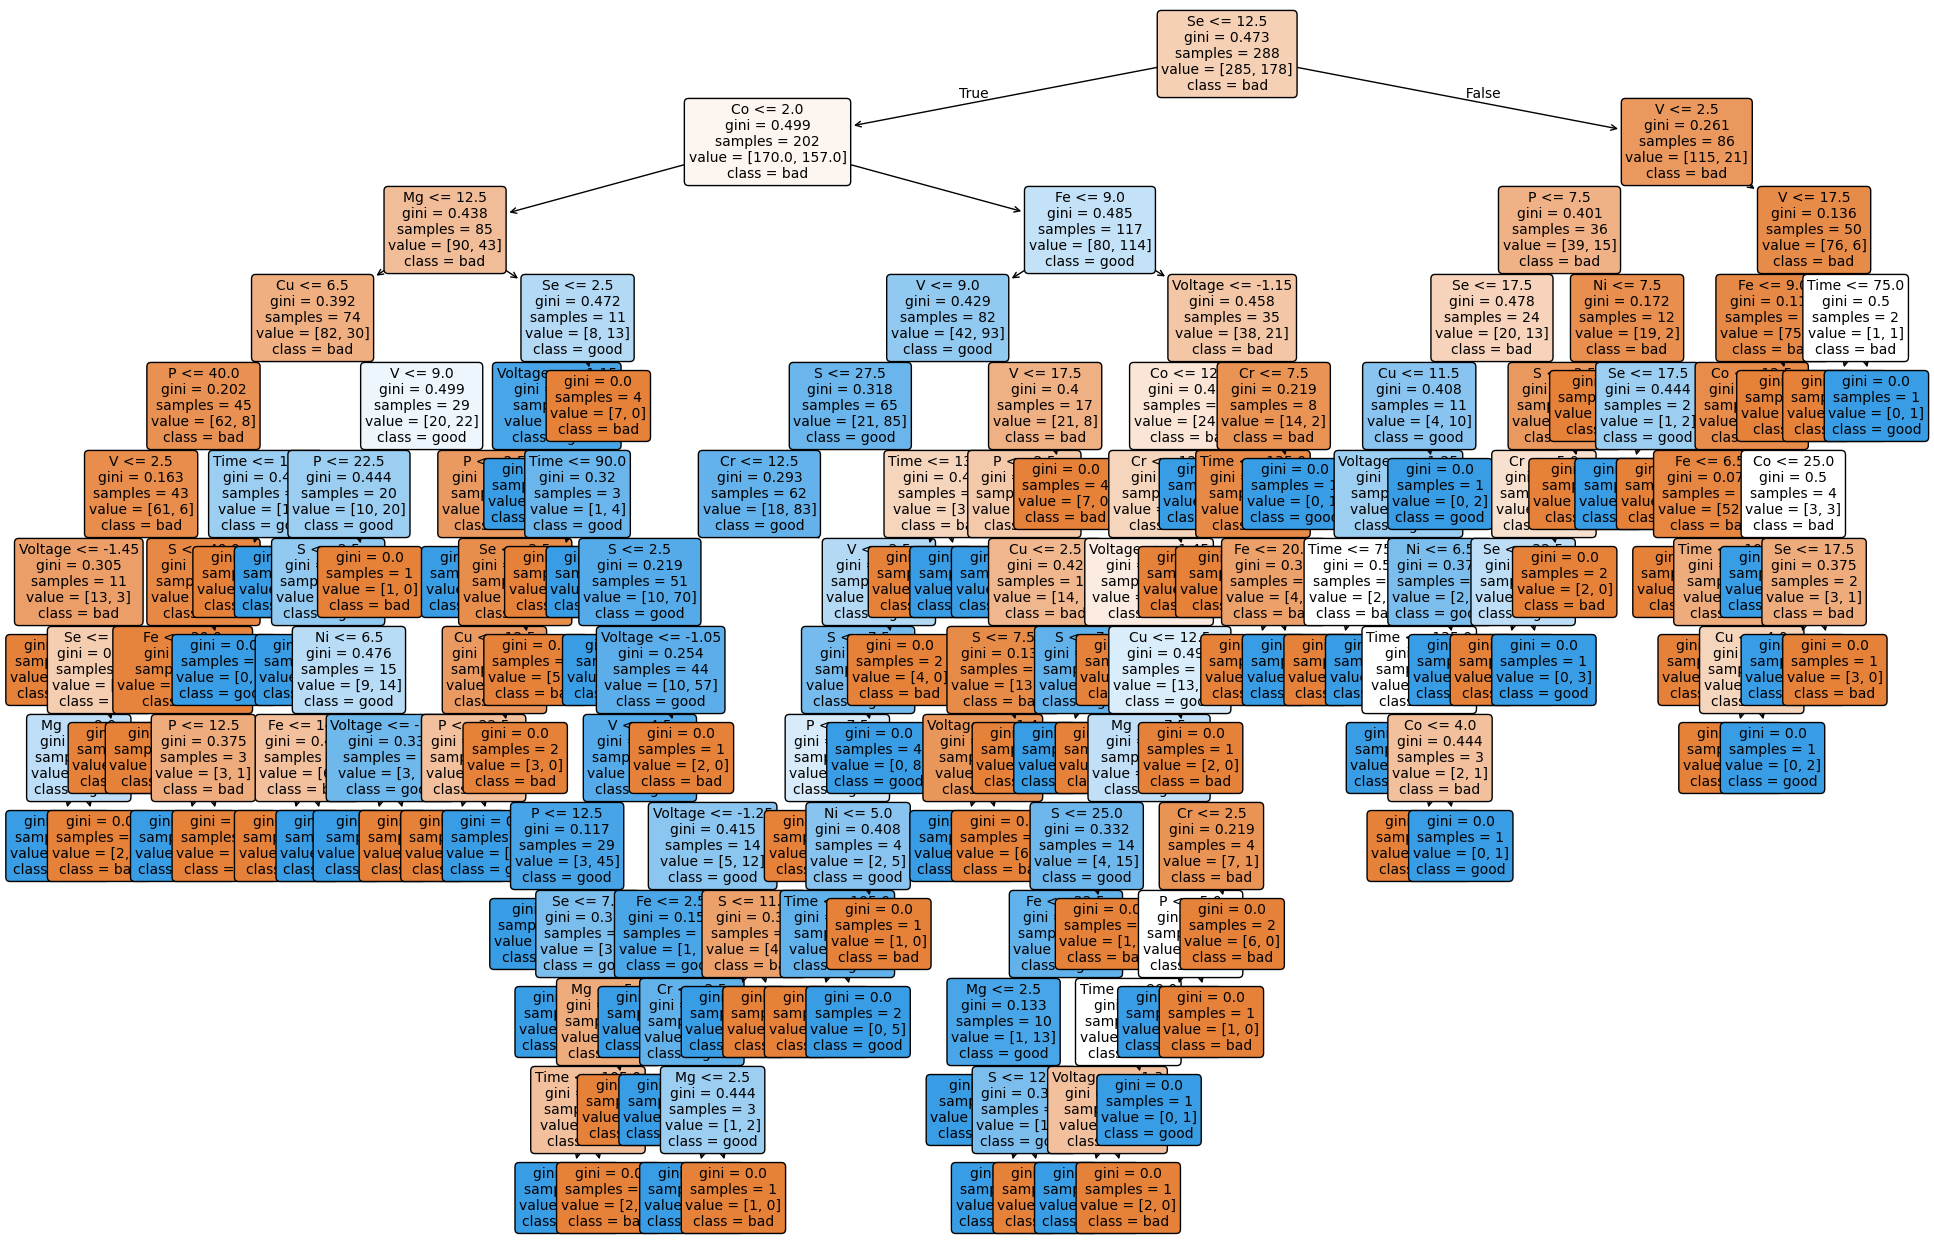


Training Set Metrics:
Precision : Mean = 0.78, Std = 0.02
Recall    : Mean = 0.72, Std = 0.02
F1        : Mean = 0.75, Std = 0.01

Validation Set Metrics:
Precision : Mean = 0.73, Std = 0.07
Recall    : Mean = 0.65, Std = 0.08
F1        : Mean = 0.68, Std = 0.04



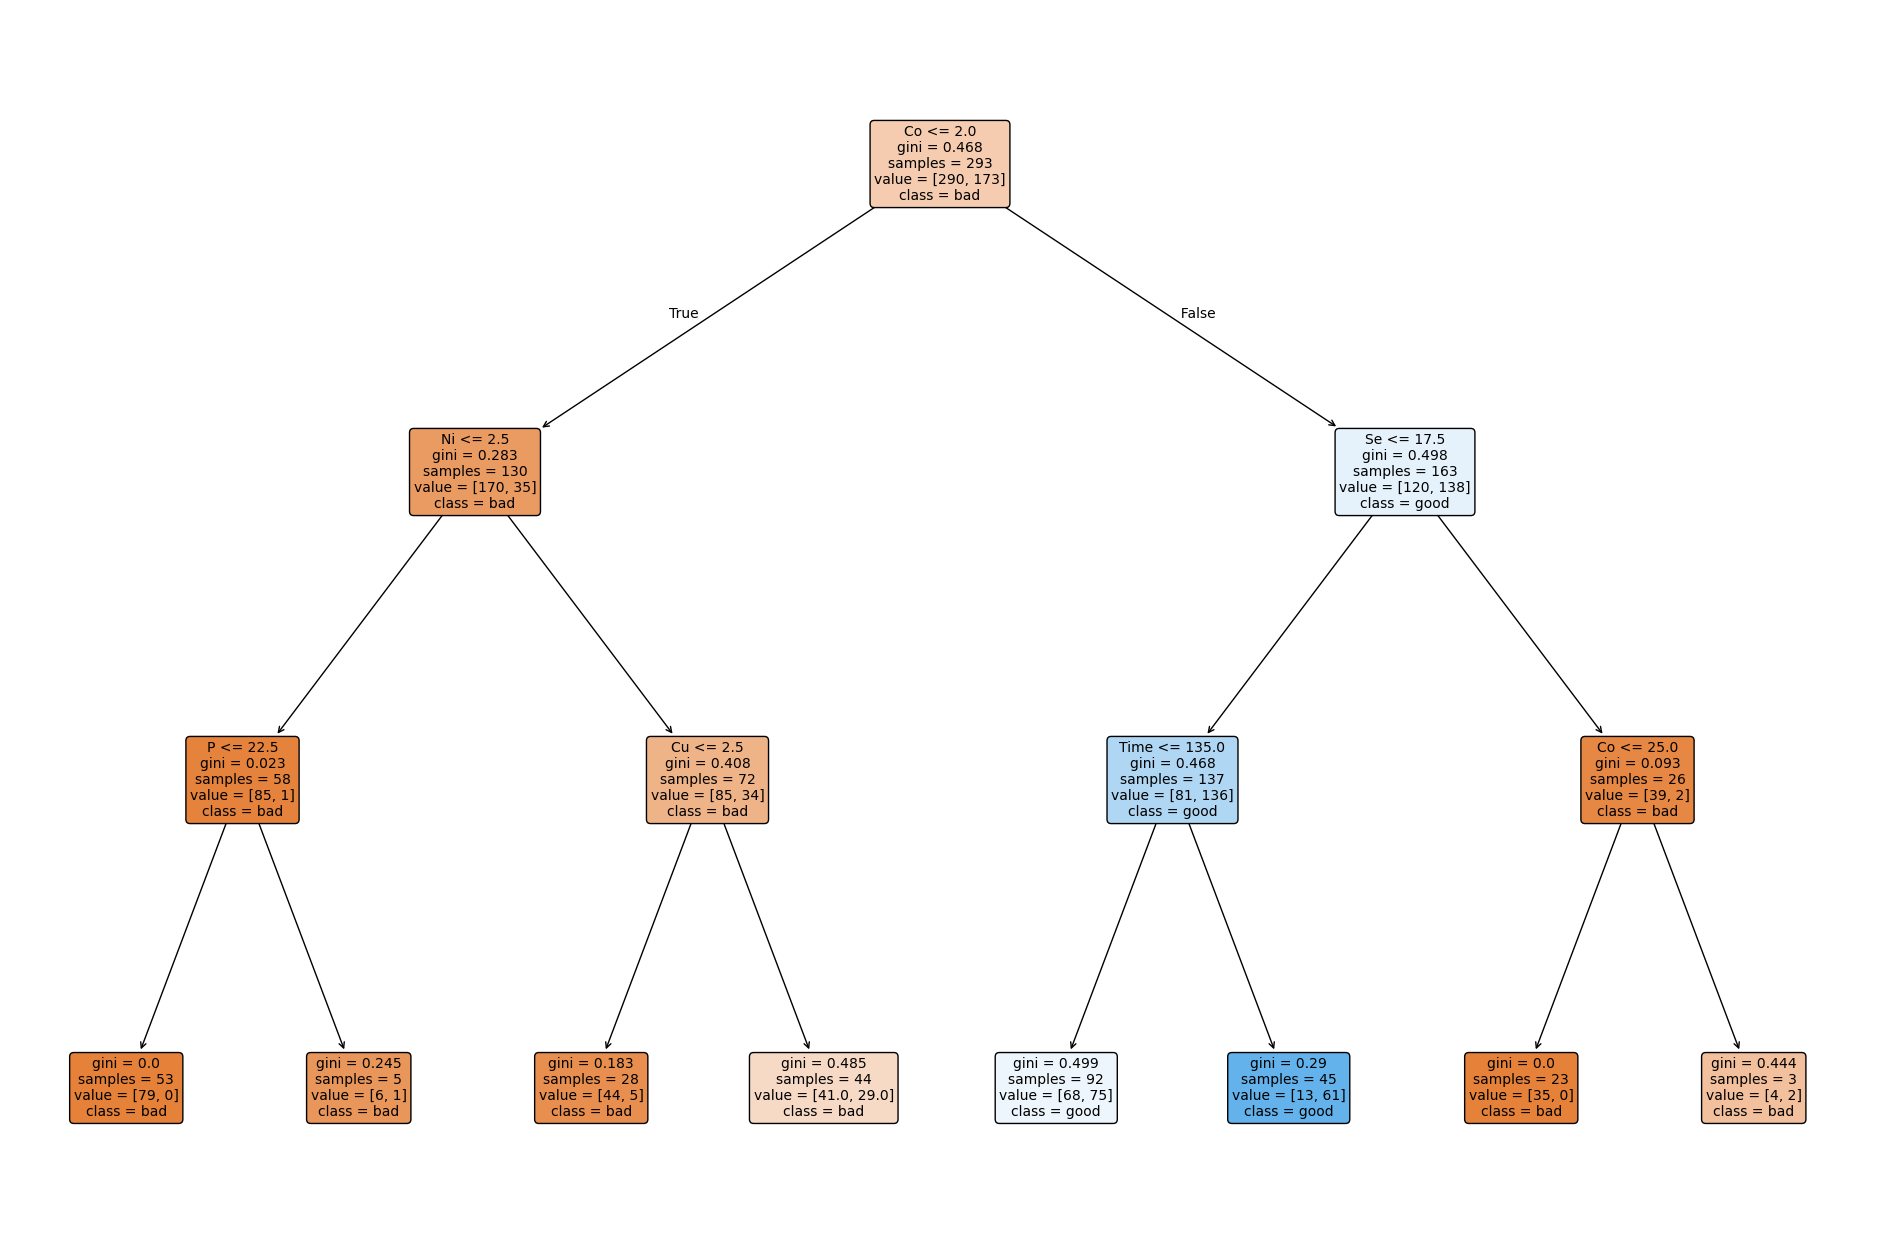


Training Set Metrics:
Precision : Mean = 0.81, Std = 0.02
Recall    : Mean = 0.75, Std = 0.02
F1        : Mean = 0.78, Std = 0.02

Validation Set Metrics:
Precision : Mean = 0.73, Std = 0.04
Recall    : Mean = 0.66, Std = 0.05
F1        : Mean = 0.69, Std = 0.03



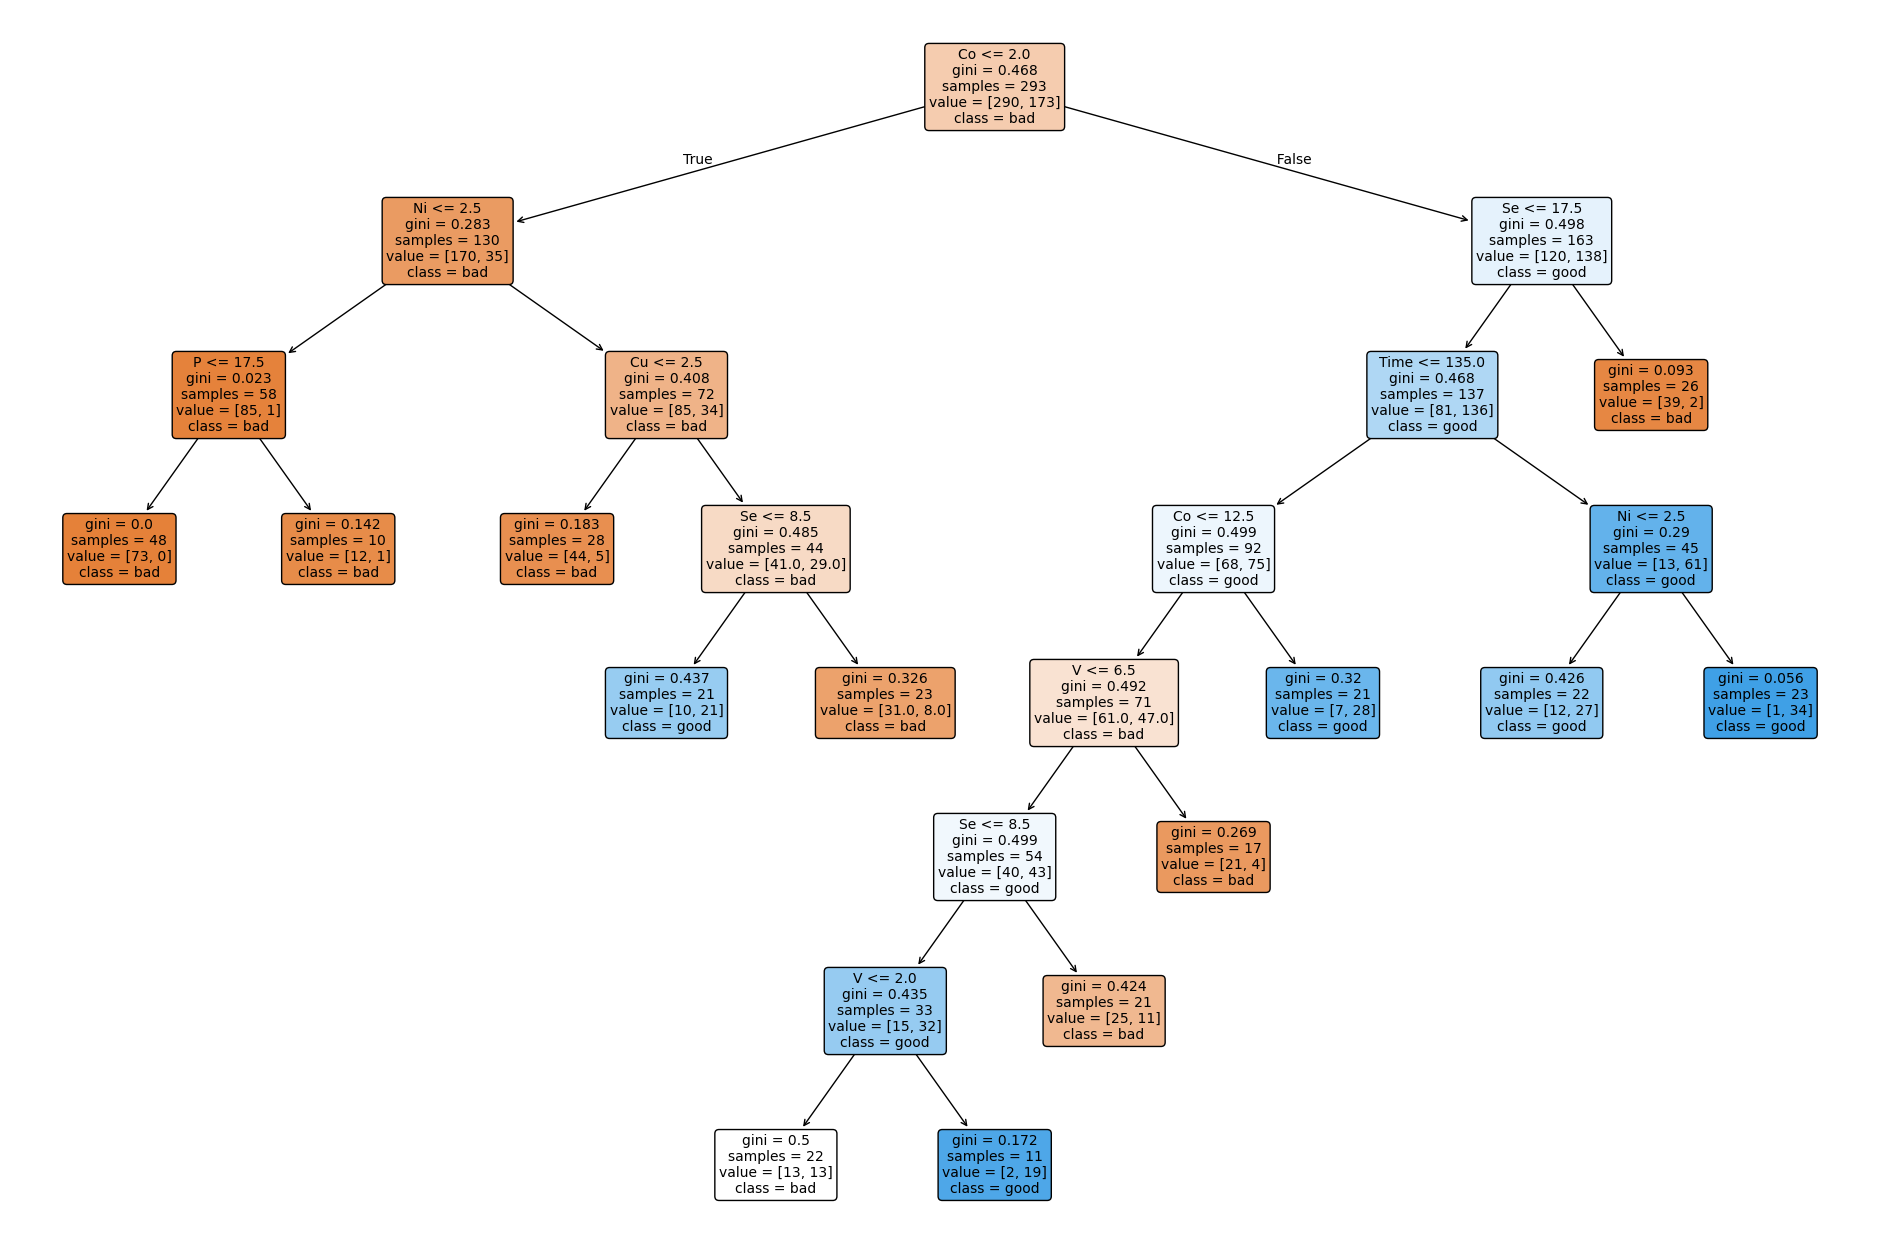


Training Set Metrics:
Precision : Mean = 0.79, Std = 0.02
Recall    : Mean = 0.73, Std = 0.02
F1        : Mean = 0.76, Std = 0.01

Validation Set Metrics:
Precision : Mean = 0.73, Std = 0.07
Recall    : Mean = 0.66, Std = 0.07
F1        : Mean = 0.69, Std = 0.04



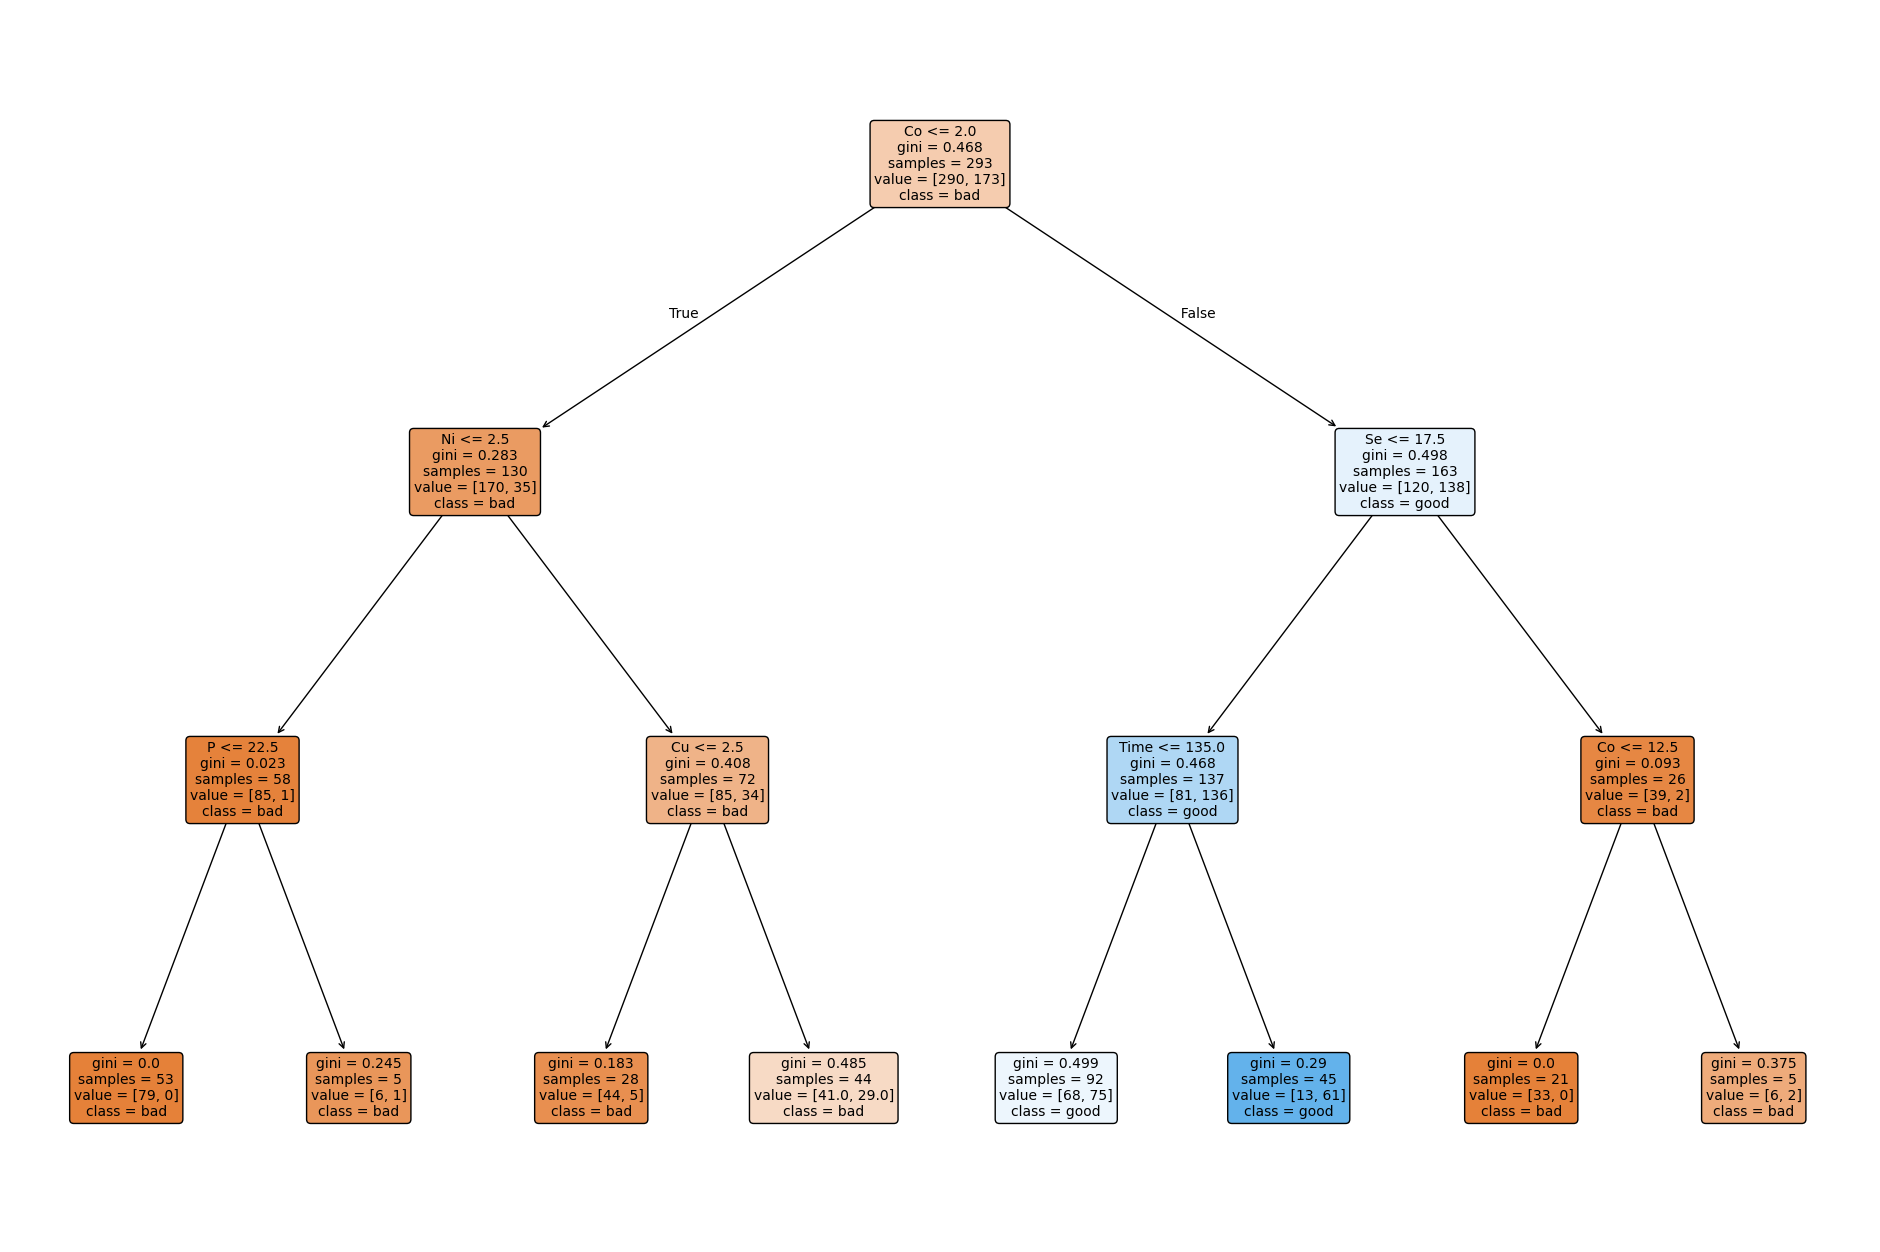


Training Set Metrics:
Precision : Mean = 0.88, Std = 0.03
Recall    : Mean = 0.80, Std = 0.02
F1        : Mean = 0.84, Std = 0.02

Validation Set Metrics:
Precision : Mean = 0.75, Std = 0.05
Recall    : Mean = 0.63, Std = 0.09
F1        : Mean = 0.68, Std = 0.05



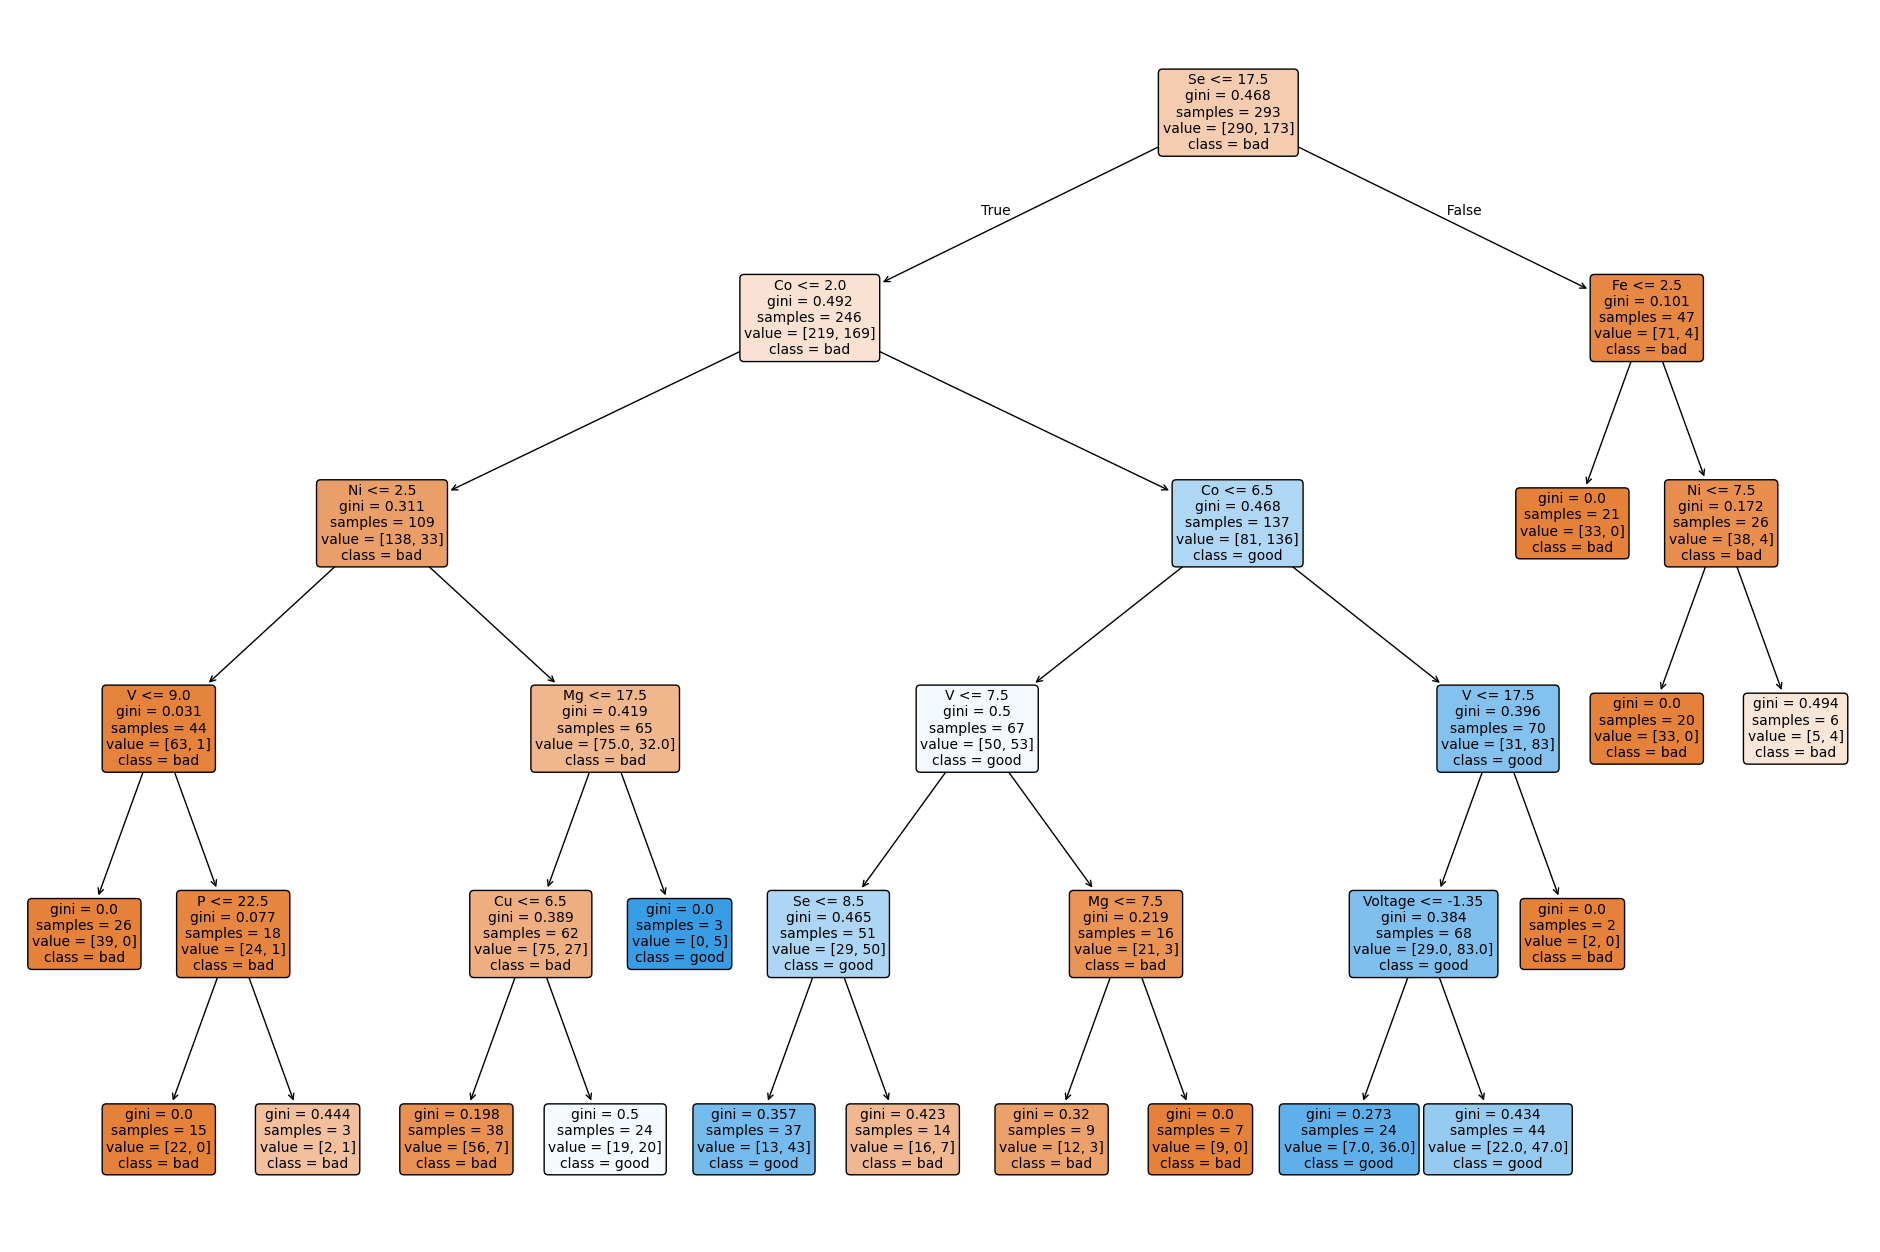

In [37]:
# Create four different sets of hyperparameters

rfc_tuned_1 = RandomForestClassifier(n_estimators=100,
                               max_depth = 3,
                               min_samples_split=10,
                               min_samples_leaf=2,  
                               max_features=None,
                               random_state=0)

rfc_tuned_2 = RandomForestClassifier(n_estimators=400,
                               max_depth = 10,
                               min_samples_split=30,
                               min_samples_leaf=10, 
                               max_features=None,
                               random_state=0)

rfc_tuned_3 = RandomForestClassifier(n_estimators=1000,
                               max_depth = 3,
                               min_samples_split=20,
                               min_samples_leaf=5, 
                               max_features=None,
                               random_state=0)

rfc_tuned_4 = RandomForestClassifier(n_estimators=700,
                               max_depth = 5,
                               min_samples_split=15,
                               min_samples_leaf=2, 
                               max_features='log2',
                               random_state=0)

"""
Calculate statistics for each set of hyperparameters after the 5-fold cross validation 
procedure of training and validation and print the first tree for each model.
"""

def metrics_and_trees(X, y, X_test, y_test, model, test_eval=False, print_trees=True):

    cv_scores(X, y, model)

    # Train model on all training + validation data before printing the first tree

    final_model = clone(model)
    final_model.fit(X, y)

    if test_eval == True:

        # Obtain test set metrics

        y_pred_test = final_model.predict(X_test)

        precision_test = precision_score(y_test, y_pred_test, pos_label='good')
        recall_test = recall_score(y_test, y_pred_test, pos_label='good')
        f1_test = f1_score(y_test, y_pred_test, pos_label='good')

        print("\nTest Set Metrics:")
        print(f"Precision = {precision_test:.2f}")
        print(f"Recall = {recall_test:.2f}")
        print(f"F1 = {f1_test:.2f}")

    if print_trees == True:
        
        tree_print(final_model, 0, features, final_model.classes_)

# Include the original model with no hyperparameters tuned for comparison

metrics_and_trees(X_train_val_1, y_rf_train_val_1, X_test, y_rf_test, rfc)

metrics_and_trees(X_train_val_1, y_rf_train_val_1, X_test, y_rf_test, rfc_tuned_1)

metrics_and_trees(X_train_val_1, y_rf_train_val_1, X_test, y_rf_test, rfc_tuned_2)

metrics_and_trees(X_train_val_1, y_rf_train_val_1, X_test, y_rf_test, rfc_tuned_3)

metrics_and_trees(X_train_val_1, y_rf_train_val_1, X_test, y_rf_test, rfc_tuned_4)

### 2.8 Selected Random Forest Model and Test Set Evaluation

Cross-validation results indicate that all tested hyperparameter configurations perform similarly on unseen validation data. Although all tuned models reduce the gap between training and validation performance compared to the base model, improvements in validation metrics are relatively small. This suggests that model performance is relatively robust to moderate changes in the tested hyperparameters.

Model 2 is selected as the final model because validation metrics are slightly better than those of the base model while also exhibiting a smaller gap between training and validation performance. This suggests that Model 2 may provide a slightly better balance between predictive performance and generalization.

Validation metrics for Model 2 are also marginally higher than those of Models 1 and 4. While Models 2 and 3 perform similarly, Model 2 exhibits slightly lower metric variability across cross-validation folds and is therefore selected as the final model.

In [38]:
metrics_and_trees(X_train_val_1, y_rf_train_val_1, X_test, y_rf_test, rfc_tuned_2, test_eval=True, print_trees=False)


Training Set Metrics:
Precision : Mean = 0.81, Std = 0.02
Recall    : Mean = 0.75, Std = 0.02
F1        : Mean = 0.78, Std = 0.02

Validation Set Metrics:
Precision : Mean = 0.73, Std = 0.04
Recall    : Mean = 0.66, Std = 0.05
F1        : Mean = 0.69, Std = 0.03


Test Set Metrics:
Precision = 0.83
Recall = 0.70
F1 = 0.76


Metrics from the test set predictions are relatively similar to those of the validation and training sets. This suggests reduced overfitting relative to the baseline model and indicates improved generalization performance. Metrics leave substantial room for improvement, however, which may be done through further tuning of hyperparameters or using other classification models, such as gradient boosting machines (e.g., XGBoost).

### 2.9 Random Forest Performance with the 80/15/5 Split

Using the selected random forest hyperparameters, the 5-fold cross-validation workflow is repeated with the second data split to see how model performance changes when more data is used for training.

In [39]:
# Create combined X and y training + validation 2 arrays

X_train_val_2 = np.concatenate((X2, X2_val),axis=0)
y_rf_train_val_2 = np.concatenate((y_rf2, y_rf2_val),axis=0)

# Calculate metrics for training and validation sets from 5-fold CV, then on the test set

metrics_and_trees(X_train_val_2, y_rf_train_val_2, X2_test, y_rf2_test, rfc_tuned_2, test_eval=True, print_trees=False)


Training Set Metrics:
Precision : Mean = 0.82, Std = 0.01
Recall    : Mean = 0.75, Std = 0.03
F1        : Mean = 0.79, Std = 0.02

Validation Set Metrics:
Precision : Mean = 0.76, Std = 0.04
Recall    : Mean = 0.67, Std = 0.03
F1        : Mean = 0.71, Std = 0.02


Test Set Metrics:
Precision = 0.70
Recall = 0.88
F1 = 0.78


The model performs similarly against the smaller test set in the second split compared to the first split, with a very minor improvement seen through the F1 score. However, the smaller test set also makes the test metrics less stable, so this comparison should be interpreted very carefully rather than treated as definitive proof that the second split gives a better model.

The slightly improved performance may be related to the larger training set, although differences should be interpreted cautiously due to the smaller test set.

## Part 3: MLP Regression

For the regression task, the overpotential value is predicted directly using multilayer perceptrons. Performance is compared with and without input normalization, then permutation feature importances are used to interpret which variables matter most.

### 3.1 Baseline MLP Without Input Normalization

First, a default MLP regressor is trained without scaling the input features. This provides a baseline for comparing whether normalization improves regression performance.

In [40]:
# Import packages

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Create MLP model

mlp = MLPRegressor(random_state=42, max_iter=1000)

# Create y variables for MLP analysis

y_mlp = y[:, 0].astype(float)
y_mlp_val = y_val[:, 0].astype(float)
y_mlp_test = y_test[:, 0].astype(float)

# Fit MLP model to training data

mlp.fit(X, y_mlp)

"""
Predict against training 1, validation 1, and test 1 splits, then calculate MSE and 
RMSE against each.
"""

y_train_pred = mlp.predict(X)
y_val_pred = mlp.predict(X_val)
y_test_pred  = mlp.predict(X_test)

mse_train = np.round(mean_squared_error(y_mlp,  y_train_pred), 2)
rmse_train  = np.round(np.sqrt(mse_train), 2)

mse_val   = np.round(mean_squared_error(y_mlp_val,  y_val_pred), 2)
rmse_val  = np.round(np.sqrt(mse_val), 2)

mse_test  = np.round(mean_squared_error(y_mlp_test, y_test_pred), 2)
rmse_test = np.round(np.sqrt(mse_test), 2)

# Print values

print(f'The MSE against training set 1 is {mse_train} and the RMSE is {rmse_train}')
print(f'The MSE against validation set 1 is {mse_val} and the RMSE is {rmse_val}')
print(f'The MSE against test set 1 is {mse_test} and the RMSE is {rmse_test}')

The MSE against training set 1 is 0.03 and the RMSE is 0.17
The MSE against validation set 1 is 0.06 and the RMSE is 0.24
The MSE against test set 1 is 0.07 and the RMSE is 0.26


### 3.2 Five-Fold Cross-Validation Without Input Normalization

In [41]:
# Import package

from sklearn.model_selection import KFold

# Create combined y training + validation 1 arrays (for MLP)

y_mlp_train_val_1 = np.concatenate((y_mlp, y_mlp_val), axis=0)

# # Create stratified k-fold variable with desired attributes

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize model

mlp = MLPRegressor(random_state=42, max_iter=1000)

# Create function to calculate means and standard deviations for each statistic of interest

def report_metrics(name, scores):
        print(f"\n{name} Set Metrics:")
        for metric in ['MSE', 'RMSE']:
            mean = np.mean(scores[metric])
            std = np.std(scores[metric])
            print(f"{metric}: Mean = {mean:.2f}, Std = {std:.2f}")

"""
Create function for training classifier on one split of training + validation data, 
then calculate statistics of interest against training and validation data
separately. Do this 5 times for 5 different splits.
"""

def cv_error_scores(X, y, model):

    # Initialize statistics arrays

    train_metrics = {'MSE': [], 'RMSE': []}
    val_metrics = {'MSE': [], 'RMSE': []}

    # Run train_test_split and create training and validation folds

    for train_index, val_index in cv_reg.split(X):
        X_tr, X_val_fold = X[train_index], X[val_index]
        y_tr, y_val_fold = y[train_index], y[val_index]

        # Train a fresh copy of the model for this fold

        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)

        # Predict against training fold
        
        y_pred_train = fold_model.predict(X_tr)
        mse_train = mean_squared_error(y_tr, y_pred_train)
        train_metrics['MSE'].append(mse_train)
        train_metrics['RMSE'].append(np.sqrt(mse_train))

        # Predict against validation fold

        y_pred_val = fold_model.predict(X_val_fold)
        mse_val = mean_squared_error(y_val_fold, y_pred_val)
        val_metrics['MSE'].append(mse_val)
        val_metrics['RMSE'].append(np.sqrt(mse_val))

    # Display results, including means and standard deviations for each statistic

    report_metrics("Training", train_metrics)
    report_metrics("Validation", val_metrics)

    print("\n ================================")

# Run function using training + validation 1 data, and obtain metrics against training 1 and validation 1 data separately

cv_error_scores(X_train_val_1, y_mlp_train_val_1, mlp)


Training Set Metrics:
MSE: Mean = 0.03, Std = 0.00
RMSE: Mean = 0.17, Std = 0.01

Validation Set Metrics:
MSE: Mean = 0.09, Std = 0.02
RMSE: Mean = 0.30, Std = 0.04



### 3.3 Five-Fold Cross-Validation With Input Normalization

Because MLPs are sensitive to feature scale, the cross-validation workflow is repeated after standardizing the input features.

In [42]:
# Import package

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Initialize model

mlp = MLPRegressor(random_state=42, max_iter=1000)

# Create pipeline for input data normalization

mlp_pipe = Pipeline([("scaler", StandardScaler()),("mlp", mlp)])

# Run function using training + validation 1 data, and obtain metrics against training 1 and validation 1 data separately

cv_error_scores(X_train_val_1, y_mlp_train_val_1, mlp_pipe)


Training Set Metrics:
MSE: Mean = 0.01, Std = 0.00
RMSE: Mean = 0.11, Std = 0.00

Validation Set Metrics:
MSE: Mean = 0.03, Std = 0.00
RMSE: Mean = 0.16, Std = 0.01



Scaled data should be used for final model development and analysis. The scaled model gives lower error without tuning, and scaling is also more appropriate for MLPs because it prevents variables with larger numerical ranges from dominating the optimization process. Because the target values are not scaled, the MSE and RMSE values can still be interpreted in terms of the original prediction target.

### 3.4 Permutation Feature Importance for Default MLP Models

Permutation feature importances (PFIs) are calculated for the default MLP models with and without input normalization. This helps compare not only predictive performance, but also which variables the model relies on most.

In [43]:
# Import package

from sklearn.inspection import permutation_importance

# Initialize MLP and train on unscaled data

mlp = MLPRegressor(random_state=42, max_iter=1000)
cv_error_scores(X_train_val_1, y_mlp_train_val_1, mlp)

# Train model on all non-test set data for feature importance analysis

mlp.fit(X_train_val_1, y_mlp_train_val_1)

# Create variable for permutation feature importances with all desired parameters (unscaled data)

perm_imp = permutation_importance(
    mlp,
    X_test,
    y_mlp_test,
    n_repeats=10,
    random_state=42
)

# Create DataFrame with results from PFI for the model with default settings

feat_importances = pd.DataFrame({
    "Feature":        features,
    "Importance Mean": np.round(perm_imp.importances_mean, 2),
    "Importance Std":  np.round(perm_imp.importances_std, 2)
}).sort_values(by="Importance Mean", ascending=False).reset_index(drop=True)

print("Permutation Feature Importance (Unscaled–Test Set)")
print(feat_importances.to_string(index=False))

# Save and print the 5 most important features based on this model

feat_1 = feat_importances.iloc[0, 0]
feat_2 = feat_importances.iloc[1, 0]
feat_3 = feat_importances.iloc[2, 0]
feat_4 = feat_importances.iloc[3, 0]
feat_5 = feat_importances.iloc[4, 0]
print('\n')
print(f"The 5 most important features based on the unscaled data for MLP are {feat_1}, {feat_2}, {feat_3}, {feat_4}, and {feat_5}.")


Training Set Metrics:
MSE: Mean = 0.03, Std = 0.00
RMSE: Mean = 0.17, Std = 0.01

Validation Set Metrics:
MSE: Mean = 0.09, Std = 0.02
RMSE: Mean = 0.30, Std = 0.04

Permutation Feature Importance (Unscaled–Test Set)
Feature  Importance Mean  Importance Std
     Se             1.05            0.40
      P             0.93            0.58
     Co             0.71            0.82
     Mg             0.60            0.46
      S             0.47            0.56
     Fe             0.14            0.33
      V             0.02            0.46
Voltage             0.01            0.06
     Cr            -0.04            0.35
   Time            -0.04            0.36
     Ni            -0.06            0.38
     Cu            -0.15            0.35


The 5 most important features based on the unscaled data for MLP are Se, P, Co, Mg, and S.


In [44]:
# Do the same thing for the scaled data, but create pipeline for normalization

mlp = MLPRegressor(random_state=42, max_iter=1000)
mlp_pipe = Pipeline([("scaler", StandardScaler()),("mlp", mlp)])

cv_error_scores(X_train_val_1, y_mlp_train_val_1, mlp_pipe)

# Train model on all non-test set data for feature importance analysis

mlp_pipe.fit(X_train_val_1, y_mlp_train_val_1)

perm_imp = permutation_importance(
    mlp_pipe,
    X_test,
    y_mlp_test,
    n_repeats=10,
    random_state=42
)

feat_importances = pd.DataFrame({
    "Feature":        features,
    "Importance Mean": np.round(perm_imp.importances_mean, 2),
    "Importance Std":  np.round(perm_imp.importances_std, 2)
}).sort_values(by="Importance Mean", ascending=False).reset_index(drop=True)

print("Permutation Feature Importance (Scaled–Test Set)")
print(feat_importances.to_string(index=False))

impfeat1 = feat_importances.iloc[0, 0]
impfeat2 = feat_importances.iloc[1, 0]
impfeat3 = feat_importances.iloc[2, 0]
impfeat4 = feat_importances.iloc[3, 0]
impfeat5 = feat_importances.iloc[4, 0]
print('\n')
print(f'The 5 most important features based on the scaled data for MLP are {impfeat1}, {impfeat2}, {impfeat3}, {impfeat4}, and {impfeat5}.')


Training Set Metrics:
MSE: Mean = 0.01, Std = 0.00
RMSE: Mean = 0.11, Std = 0.00

Validation Set Metrics:
MSE: Mean = 0.03, Std = 0.00
RMSE: Mean = 0.16, Std = 0.01

Permutation Feature Importance (Scaled–Test Set)
Feature  Importance Mean  Importance Std
     Co             0.51            0.12
     Ni             0.46            0.06
     Se             0.44            0.14
      P             0.14            0.05
Voltage             0.11            0.06
      S             0.08            0.04
   Time             0.08            0.06
     Mg             0.06            0.04
     Cr             0.05            0.09
      V             0.04            0.07
     Fe            -0.00            0.05
     Cu            -0.06            0.04


The 5 most important features based on the scaled data for MLP are Co, Ni, Se, P, and Voltage.


### 3.5 MLP Hyperparameter Tuning

Using the scaled input data, four MLP hyperparameter combinations are tested and cross-validation performance is compared.

In [45]:
# Create 4 different sets of hyperparameters

mlpparams1 = {"hidden_layer_sizes": (25, 50, 25, 30, 25),
    "activation": 'relu',
    "solver": 'adam',
    "alpha": 1e-4,
    "learning_rate_init": 0.1e-3,
    "max_iter": 1000,
    "random_state": 42}

mlpparams2 = {"hidden_layer_sizes": (100, 200, 5, 100),
    "activation": 'relu',
    "solver": 'adam',
    "alpha": 1e-4,
    "learning_rate_init": 1e-3,
    "max_iter": 1000,
    "random_state": 42}

mlpparams3 = {"hidden_layer_sizes": (50, 25),
    "activation": 'relu',
    "solver": 'adam',
    "alpha": 5e-4,
    "learning_rate_init": 1e-3,
    "max_iter": 1000,
    "random_state": 42}

mlpparams4 = {"hidden_layer_sizes": (50, 25),
    "activation": 'relu',
    "solver": 'adam',
    "alpha": 1e-4,
    "learning_rate_init": 5e-3,
    "max_iter": 1000,
    "random_state": 42}

"""
Calculate statistics for each set of hyperparameters after the 5-fold cross validation 
procedure of training and validation.
"""

param_options = [mlpparams1, mlpparams2, mlpparams3, mlpparams4]

for params in param_options:
    mlp = MLPRegressor(**params)
    mlp_pipe = Pipeline([("scaler", StandardScaler()),("mlp", mlp)])
    cv_error_scores(X_train_val_1, y_mlp_train_val_1, mlp_pipe)


Training Set Metrics:
MSE: Mean = 0.02, Std = 0.00
RMSE: Mean = 0.15, Std = 0.00

Validation Set Metrics:
MSE: Mean = 0.03, Std = 0.00
RMSE: Mean = 0.16, Std = 0.01


Training Set Metrics:
MSE: Mean = 0.01, Std = 0.00
RMSE: Mean = 0.10, Std = 0.00

Validation Set Metrics:
MSE: Mean = 0.01, Std = 0.00
RMSE: Mean = 0.12, Std = 0.01


Training Set Metrics:
MSE: Mean = 0.01, Std = 0.00
RMSE: Mean = 0.10, Std = 0.00

Validation Set Metrics:
MSE: Mean = 0.02, Std = 0.00
RMSE: Mean = 0.14, Std = 0.01


Training Set Metrics:
MSE: Mean = 0.00, Std = 0.00
RMSE: Mean = 0.06, Std = 0.00

Validation Set Metrics:
MSE: Mean = 0.02, Std = 0.00
RMSE: Mean = 0.13, Std = 0.01



### 3.6 Selected MLP Model

The second set of parameters appears to be the best option because the MSE and RMSE values are relatively low while remaining reasonably comparable across the training and validation sets. This suggests that the model is fitting the data without showing the same level of overfitting as some more aggressive model settings (such as set 4). 

### 3.7 Final MLP Feature Importance

In [46]:
# Create MLP model with best set of hyperparameters

mlpfinal = MLPRegressor(**mlpparams2)
mlp_pipe_final = Pipeline([("scaler", StandardScaler()),("mlp", mlpfinal)])

# Evaluate MLP model with cross-validation

cv_error_scores(X_train_val_1, y_mlp_train_val_1, mlp_pipe_final)

# Train model on all non-test set data for test set prediction performance evaluation

mlp_pipe_final.fit(X_train_val_1, y_mlp_train_val_1)

# Show final test set metrics

y_pred_test = mlp_pipe_final.predict(X_test)

mse_test = mean_squared_error(y_mlp_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print(f"\nTest Set Metrics:")
print(f"MSE = {mse_test:.2f}")
print(f"RMSE = {rmse_test:.2f}")

# Do the same thing for PFI for the final model as was done for the scaled and unscaled data

perm_imp = permutation_importance(
    mlp_pipe_final,
    X_test,
    y_mlp_test,
    n_repeats=10,
    random_state=42
)
feat_importances = pd.DataFrame({
    "Feature":        features,
    "Importance Mean": np.round(perm_imp.importances_mean, 2),
    "Importance Std":  np.round(perm_imp.importances_std, 2)
}).sort_values(by="Importance Mean", ascending=False).reset_index(drop=True)

print("\nPermutation Feature Importance (Scaled–Test Set)")
print(feat_importances.to_string(index=False))

feat_1 = feat_importances.iloc[0, 0]
feat_2 = feat_importances.iloc[1, 0]
feat_3 = feat_importances.iloc[2, 0]
feat_4 = feat_importances.iloc[3, 0]
feat_5 = feat_importances.iloc[4, 0]
print('\n')
print(f'The 5 most important features based on the final model for MLP are {feat_1}, {feat_2}, {feat_3}, {feat_4}, and {feat_5}.')


Training Set Metrics:
MSE: Mean = 0.01, Std = 0.00
RMSE: Mean = 0.10, Std = 0.00

Validation Set Metrics:
MSE: Mean = 0.01, Std = 0.00
RMSE: Mean = 0.12, Std = 0.01


Test Set Metrics:
MSE = 0.01
RMSE = 0.11

Permutation Feature Importance (Scaled–Test Set)
Feature  Importance Mean  Importance Std
     Co             0.59            0.10
     Se             0.26            0.05
     Ni             0.25            0.04
      V             0.14            0.04
   Time             0.09            0.04
Voltage             0.05            0.03
     Cr             0.04            0.04
      P             0.03            0.02
     Mg             0.02            0.02
     Fe             0.02            0.02
     Cu             0.01            0.02
      S             0.00            0.02


The 5 most important features based on the final model for MLP are Co, Se, Ni, V, and Time.


The top features from the final tuned MLP are different from the default-model rankings in the earlier PFI analysis. This is expected because hyperparameter tuning changes how the model fits the data, and scaling changes how the model handles variables with different numerical ranges.

The feature importance results should therefore be interpreted as model-dependent rather than as one universal ranking of chemical importance. PFI analysis is useful here because it shows which features are most influential for a specific trained model, but the ranking can shift when the model architecture, training behavior, or preprocessing changes.

The final model gives somewhat low and consistent errors over all data splits (including the test set), indicating minimal overfitting. Therefore, this appears to be a reasonable model choice for catalyst overpotential prediction within this hydrogen evolution reaction dataset. To improve performance, other ML models may be tested, and hyperparameters may be further tuned, as only one type of neural network and a limited number of hyperparameter configurations are tested. 

This model should not be generalized beyond the specific chemical reaction used to generate the initial data.